In [1]:
import pandas as pd
import utility as ut
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_quality_metrics(simulation_result, setpoints):
    NUM_STEPS = len(simulation_result["time"])
    time = [simulation_result["time"][i] for i in range(NUM_STEPS)]
    trolley_position = [
        simulation_result["trolley_position"][i] for i in range(NUM_STEPS)
    ]
    cable_length = [simulation_result["cable_length"][i] for i in range(NUM_STEPS)]
    sway_angle = [simulation_result["sway_angle"][i] for i in range(NUM_STEPS)]

    # Calculate rise time, settling time, overshoot, and RMSE for x
    rise_10_index_x, rise_90_index_x = ut.get_rise_index(trolley_position, setpoints["x"])
    rise_time_x = time[rise_90_index_x] - time[rise_10_index_x]
    settling_index_x = ut.get_settling_index(
        trolley_position, setpoints["x"], threshold=0.05
    )
    settling_time_x = time[settling_index_x] - time[0]
    overshoot_index_x = ut.get_overshoot_index(trolley_position, setpoints["x"])
    overshoot_x = (
        trolley_position[overshoot_index_x] - setpoints["x"]
        if overshoot_index_x < NUM_STEPS
        else 0
    )
    RMSE_x = ut.get_RMSE_settle(trolley_position[settling_index_x:], setpoints["x"])

    # Calculate rise time, settling time, overshoot, and RMSE for l
    rise_10_index_l, rise_90_index_l = ut.get_rise_index(cable_length, setpoints["l"])
    rise_time_l = time[rise_90_index_l] - time[rise_10_index_l]
    settling_index_l = ut.get_settling_index(cable_length, setpoints["l"], threshold=0.05)
    settling_time_l = time[settling_index_l] - time[0]
    overshoot_index_l = ut.get_overshoot_index(cable_length, setpoints["l"])
    overshoot_l = (
        cable_length[overshoot_index_l] - setpoints["l"]
        if overshoot_index_l < NUM_STEPS
        else 0
    )
    RMSE_l = ut.get_RMSE_settle(cable_length[settling_index_l:], setpoints["l"])

    # Calculate settling time and RMSE for theta
    settling_index_theta = ut.get_settling_index(
        sway_angle, 0, threshold=0.02
    )  # threshold = 0.01 rad = 0.57 deg
    settling_time_theta = time[settling_index_theta] - time[0]
    RMSE_theta = ut.get_RMSE_settle(sway_angle[settling_index_theta:], 0)
    max_amplitude_theta = np.max(np.abs(sway_angle))

    return {
        "rise_time_x": rise_time_x,
        "settling_time_x": settling_time_x,
        "overshoot_x": overshoot_x,
        "RMSE_x": RMSE_x,
        "rise_time_l": rise_time_l,
        "settling_time_l": settling_time_l,
        "overshoot_l": overshoot_l,
        "RMSE_l": RMSE_l,
        "settling_time_theta": settling_time_theta,
        "RMSE_theta": np.rad2deg(RMSE_theta),
        "max_amplitude_theta": np.rad2deg(max_amplitude_theta),
    }

In [3]:
FOLDER_PATH = 'compare_controllers/'
PINN_AND_PID_FILE_NAME = 'Data Eksperimen PINN.xlsx'
PINN_SHEET_NAME = 'Dengan panjang tali'
PID_SHEET_NAME = 'PID'

SMC_FILE_NAME = 'sliding_mode_controller_control_gantry_crane_data.xlsx'

In [4]:
SMC_data = pd.read_excel(FOLDER_PATH + SMC_FILE_NAME)

PINN_data = pd.read_excel(FOLDER_PATH + PINN_AND_PID_FILE_NAME, sheet_name=PINN_SHEET_NAME)

PID_data = pd.read_excel(FOLDER_PATH + PINN_AND_PID_FILE_NAME, sheet_name=PID_SHEET_NAME)

In [5]:
SMC_dataset = {
    "time": np.array(SMC_data["timestamp"]),
    "trolley_position": np.array(SMC_data["trolley_position"]),
    "cable_length": np.array(SMC_data["cable_length"]),
    "sway_angle": np.array(SMC_data["sway_angle"]),
    "pwm_trolley_motor": np.array(SMC_data["pwm_trolley_motor"]),
    "pwm_hoist_motor": np.array(SMC_data["pwm_hoist_motor"]),
}
SMC_dataset["time"] = SMC_dataset["time"] - SMC_dataset["time"][0]

PINN_dataset = {
    "time": np.array(PINN_data["timestamp"]),
    "trolley_position": np.array(PINN_data["trolley_position"]),
    "cable_length": np.array(PINN_data["cable_length"]),
    "sway_angle": np.array(PINN_data["sway_angle"]),
    "pwm_trolley_motor": np.array(PINN_data["pwm_trolley_motor"]),
    "pwm_hoist_motor": np.array(PINN_data["pwm_hoist_motor"]),
}
PINN_dataset["time"] = PINN_dataset["time"] - PINN_dataset["time"][0]

PID_dataset = {
    "time": np.array(PID_data["timestamp"]),
    "trolley_position": np.array(PID_data["trolley_position"]),
    "cable_length": np.array(PID_data["cable_length"]),
    "sway_angle": np.array(PID_data["sway_angle"]),
    "pwm_trolley_motor": np.array(PID_data["pwm_trolley_motor"]),
    "pwm_hoist_motor": np.array(PID_data["pwm_hoist_motor"]),
}
PID_dataset["time"] = PID_dataset["time"] - PID_dataset["time"][0]

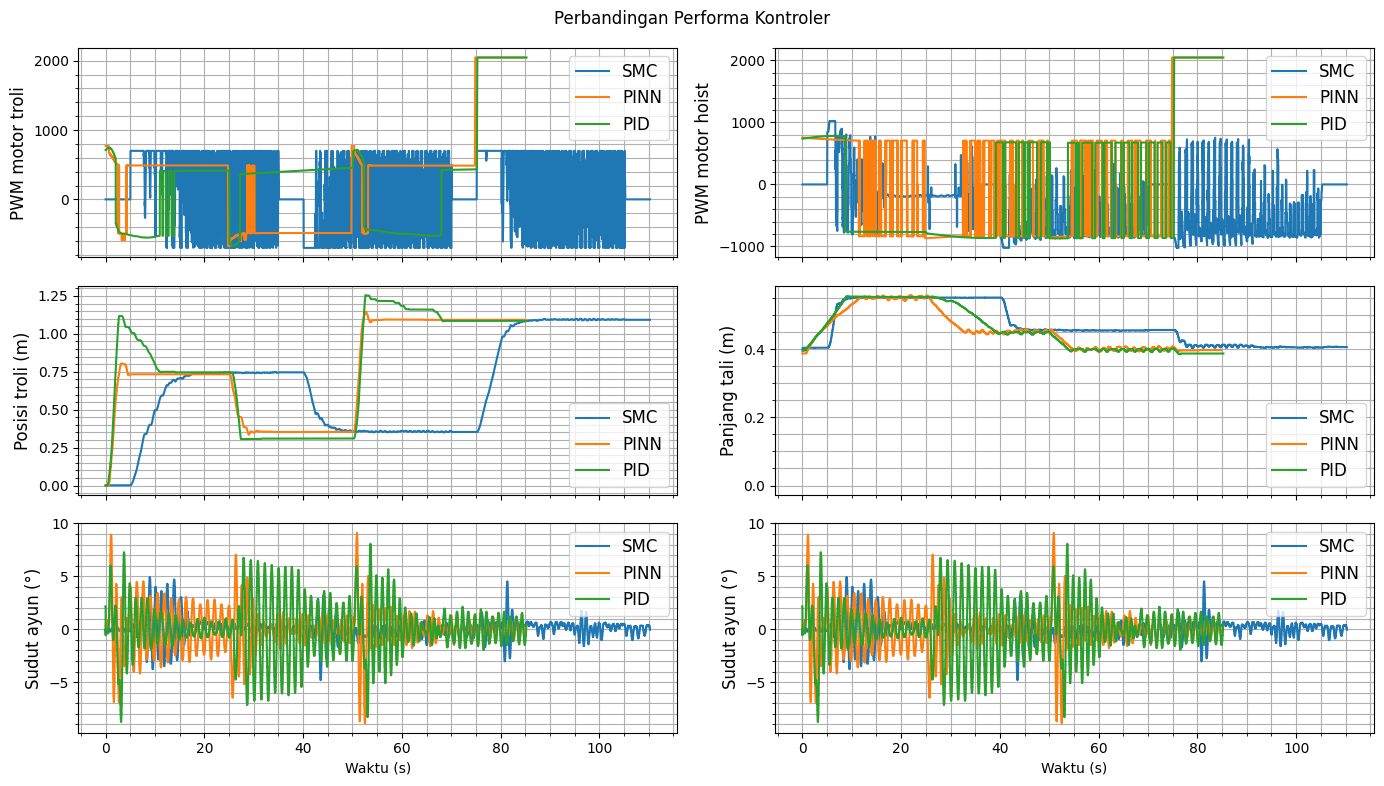

In [6]:
figure, axis = plt.subplots(3, 2, figsize=(14, 8), sharex=True)
title = "Perbandingan Performa Kontroler"
plt.rcParams.update({"font.size": 12})
figure.suptitle(title, fontsize=12)

# SMC
ut.add_to_subplot(axis[0, 0], SMC_dataset["time"], SMC_dataset["pwm_trolley_motor"], ylabel="SMC", color=plt.get_cmap("tab20")(0), linestyle="solid")
ut.add_to_subplot(axis[0, 1], SMC_dataset["time"], SMC_dataset["pwm_hoist_motor"], ylabel="SMC", color=plt.get_cmap("tab20")(0), linestyle="solid")
ut.add_to_subplot(axis[1, 0], SMC_dataset["time"], SMC_dataset["trolley_position"], ylabel="SMC", color=plt.get_cmap("tab20")(0), linestyle="solid")
ut.add_to_subplot(axis[1, 1], SMC_dataset["time"], SMC_dataset["cable_length"], ylabel="SMC", color=plt.get_cmap("tab20")(0), linestyle="solid")
ut.add_to_subplot(axis[2, 0], SMC_dataset["time"], np.rad2deg(SMC_dataset["sway_angle"]), ylabel="SMC", color=plt.get_cmap("tab20")(0), linestyle="solid")
ut.add_to_subplot(axis[2, 1], SMC_dataset["time"], np.rad2deg(SMC_dataset["sway_angle"]), ylabel="SMC", color=plt.get_cmap("tab20")(0), linestyle="solid")

# PINN
ut.add_to_subplot(axis[0, 0], PINN_dataset["time"], PINN_dataset["pwm_trolley_motor"], ylabel="PINN", color=plt.get_cmap("tab20")(2), linestyle="solid")
ut.add_to_subplot(axis[0, 1], PINN_dataset["time"], PINN_dataset["pwm_hoist_motor"], ylabel="PINN", color=plt.get_cmap("tab20")(2), linestyle="solid")
ut.add_to_subplot(axis[1, 0], PINN_dataset["time"], PINN_dataset["trolley_position"], ylabel="PINN", color=plt.get_cmap("tab20")(2), linestyle="solid")
ut.add_to_subplot(axis[1, 1], PINN_dataset["time"], PINN_dataset["cable_length"], ylabel="PINN", color=plt.get_cmap("tab20")(2), linestyle="solid")
ut.add_to_subplot(axis[2, 0], PINN_dataset["time"], np.rad2deg(PINN_dataset["sway_angle"]), ylabel="PINN", color=plt.get_cmap("tab20")(2), linestyle="solid")
ut.add_to_subplot(axis[2, 1], PINN_dataset["time"], np.rad2deg(PINN_dataset["sway_angle"]), ylabel="PINN", color=plt.get_cmap("tab20")(2), linestyle="solid")

# PID
ut.add_to_subplot(axis[0, 0], PID_dataset["time"], PID_dataset["pwm_trolley_motor"], ylabel="PID", color=plt.get_cmap("tab20")(4), linestyle="solid")
ut.add_to_subplot(axis[0, 1], PID_dataset["time"], PID_dataset["pwm_hoist_motor"], ylabel="PID", color=plt.get_cmap("tab20")(4), linestyle="solid")
ut.add_to_subplot(axis[1, 0], PID_dataset["time"], PID_dataset["trolley_position"], ylabel="PID", color=plt.get_cmap("tab20")(4), linestyle="solid")
ut.add_to_subplot(axis[1, 1], PID_dataset["time"], PID_dataset["cable_length"], ylabel="PID", color=plt.get_cmap("tab20")(4), linestyle="solid")
ut.add_to_subplot(axis[2, 0], PID_dataset["time"], np.rad2deg(PID_dataset["sway_angle"]), ylabel="PID", color=plt.get_cmap("tab20")(4), linestyle="solid")
ut.add_to_subplot(axis[2, 1], PID_dataset["time"], np.rad2deg(PID_dataset["sway_angle"]), ylabel="PID", color=plt.get_cmap("tab20")(4), linestyle="solid")

# Add legend
axis[0, 0].legend()
axis[0, 1].legend()
axis[1, 0].legend()
axis[1, 1].legend()
axis[2, 0].legend()
axis[2, 1].legend()

# Set x-axis label
axis[2, 0].set_xlabel("Waktu (s)")
axis[2, 1].set_xlabel("Waktu (s)")

# Set y-axis label
axis[0, 0].set_ylabel("PWM motor troli", fontsize=12)
axis[0, 1].set_ylabel("PWM motor hoist", fontsize=12)
axis[1, 0].set_ylabel("Posisi troli (m)", fontsize=12)
axis[1, 1].set_ylabel("Panjang tali (m)", fontsize=12)
axis[2, 0].set_ylabel("Sudut ayun (°)", fontsize=12)
axis[2, 1].set_ylabel("Sudut ayun (°)", fontsize=12)


plt.tight_layout()
plt.show()

In [7]:
DURATION = 25

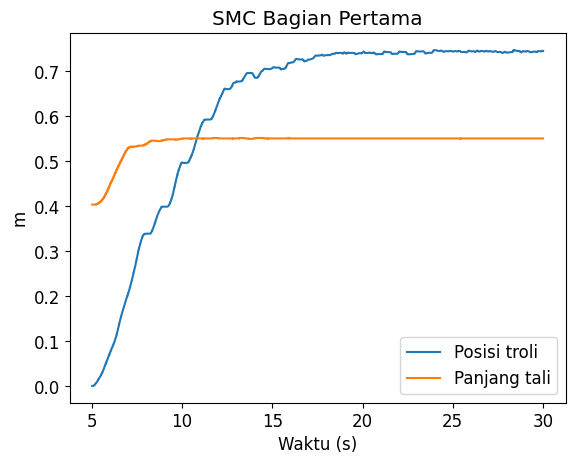

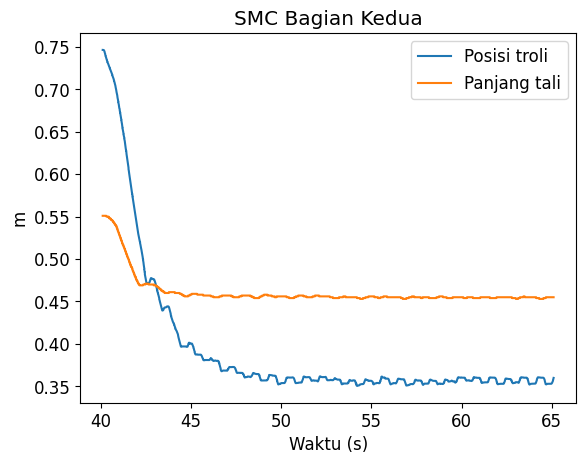

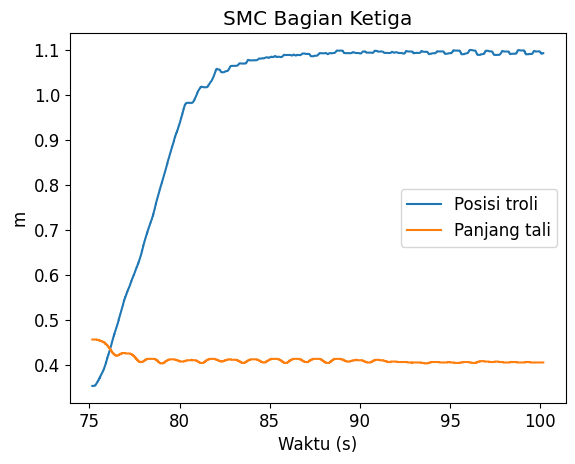

In [8]:
SMC_total_time = SMC_dataset["time"][-1]

SMC_first_section_start_index = len(SMC_dataset["time"]) - 1
for i in range(len(SMC_dataset["time"])):
    if SMC_dataset["pwm_trolley_motor"][i] != 0:
        SMC_first_section_start_index = i
        break

SMC_first_section_end_index = len(SMC_dataset["time"]) - 1
SMC_first_section_start_time = SMC_dataset["time"][SMC_first_section_start_index]
for i in range(SMC_first_section_start_index, len(SMC_dataset["time"])):
    if SMC_dataset["time"][i] - SMC_first_section_start_time > DURATION:
        SMC_first_section_end_index = i
        break

SMC_first_section = {
    "time": SMC_dataset["time"][SMC_first_section_start_index:SMC_first_section_end_index],
    "trolley_position": SMC_dataset["trolley_position"][SMC_first_section_start_index:SMC_first_section_end_index],
    "cable_length": SMC_dataset["cable_length"][SMC_first_section_start_index:SMC_first_section_end_index],
    "sway_angle": SMC_dataset["sway_angle"][SMC_first_section_start_index:SMC_first_section_end_index],
    "pwm_trolley_motor": SMC_dataset["pwm_trolley_motor"][SMC_first_section_start_index:SMC_first_section_end_index],
    "pwm_hoist_motor": SMC_dataset["pwm_hoist_motor"][SMC_first_section_start_index:SMC_first_section_end_index],
}

SMC_second_section_start_index = SMC_first_section_end_index
for i in range(SMC_first_section_end_index, len(SMC_dataset["time"])):
    if SMC_dataset["time"][i] > SMC_total_time / 3 and SMC_dataset["pwm_trolley_motor"][i] != 0:
        SMC_second_section_start_index = i
        break

SMC_second_section_end_index = len(SMC_dataset["time"]) - 1
SMC_second_section_start_time = SMC_dataset["time"][SMC_second_section_start_index]
for i in range(SMC_second_section_start_index, len(SMC_dataset["time"])):
    if SMC_dataset["time"][i] - SMC_second_section_start_time > DURATION:
        SMC_second_section_end_index = i
        break

SMC_second_section = {
    "time": SMC_dataset["time"][SMC_second_section_start_index:SMC_second_section_end_index],
    "trolley_position": SMC_dataset["trolley_position"][SMC_second_section_start_index:SMC_second_section_end_index],
    "cable_length": SMC_dataset["cable_length"][SMC_second_section_start_index:SMC_second_section_end_index],
    "sway_angle": SMC_dataset["sway_angle"][SMC_second_section_start_index:SMC_second_section_end_index],
    "pwm_trolley_motor": SMC_dataset["pwm_trolley_motor"][SMC_second_section_start_index:SMC_second_section_end_index],
    "pwm_hoist_motor": SMC_dataset["pwm_hoist_motor"][SMC_second_section_start_index:SMC_second_section_end_index],
}

SMC_third_section_start_index = SMC_second_section_end_index
for i in range(SMC_second_section_end_index, len(SMC_dataset["time"])):
    if SMC_dataset["time"][i] > 2 * SMC_total_time / 3 and SMC_dataset["pwm_trolley_motor"][i] != 0:
        SMC_third_section_start_index = i
        break

SMC_third_section_end_index = len(SMC_dataset["time"]) - 1
SMC_third_section_start_time = SMC_dataset["time"][SMC_third_section_start_index]
for i in range(SMC_third_section_start_index, len(SMC_dataset["time"])):
    if SMC_dataset["time"][i] - SMC_third_section_start_time > DURATION:
        SMC_third_section_end_index = i
        break

SMC_third_section = {
    "time": SMC_dataset["time"][SMC_third_section_start_index:SMC_third_section_end_index],
    "trolley_position": SMC_dataset["trolley_position"][SMC_third_section_start_index:SMC_third_section_end_index],
    "cable_length": SMC_dataset["cable_length"][SMC_third_section_start_index:SMC_third_section_end_index],
    "sway_angle": SMC_dataset["sway_angle"][SMC_third_section_start_index:SMC_third_section_end_index],
    "pwm_trolley_motor": SMC_dataset["pwm_trolley_motor"][SMC_third_section_start_index:SMC_third_section_end_index],
    "pwm_hoist_motor": SMC_dataset["pwm_hoist_motor"][SMC_third_section_start_index:SMC_third_section_end_index],
}

plt.plot(SMC_first_section["time"], SMC_first_section["trolley_position"], label="Posisi troli")
plt.plot(SMC_first_section["time"], SMC_first_section["cable_length"], label="Panjang tali")
plt.xlabel("Waktu (s)")
plt.ylabel("m")
plt.title("SMC Bagian Pertama")
plt.legend()
plt.show()

plt.plot(SMC_second_section["time"], SMC_second_section["trolley_position"], label="Posisi troli")
plt.plot(SMC_second_section["time"], SMC_second_section["cable_length"], label="Panjang tali")
plt.xlabel("Waktu (s)")
plt.ylabel("m")
plt.title("SMC Bagian Kedua")
plt.legend()
plt.show()

plt.plot(SMC_third_section["time"], SMC_third_section["trolley_position"], label="Posisi troli")
plt.plot(SMC_third_section["time"], SMC_third_section["cable_length"], label="Panjang tali")
plt.xlabel("Waktu (s)")
plt.ylabel("m")
plt.title("SMC Bagian Ketiga")
plt.legend()
plt.show()

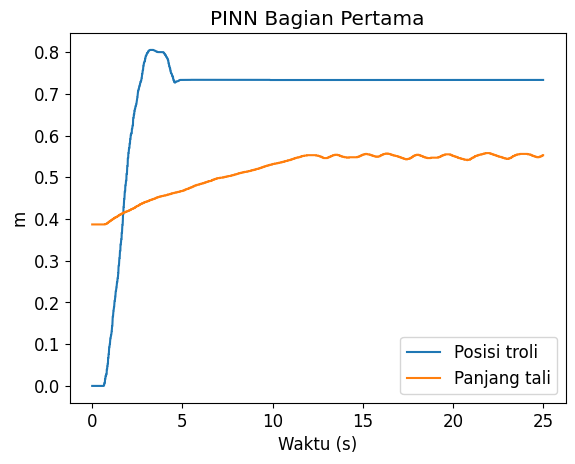

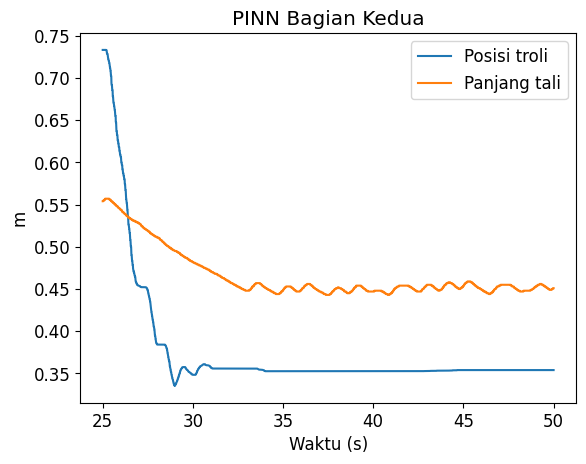

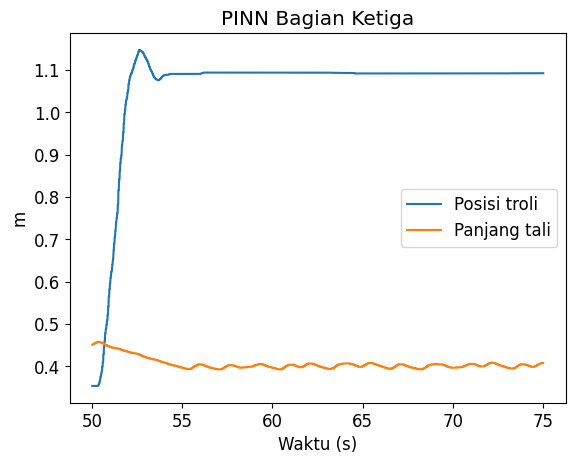

In [9]:
PINN_total_time = PINN_dataset["time"][-1]

PINN_first_section_start_index = len(PINN_dataset["time"]) - 1
for i in range(len(PINN_dataset["time"])):
    if PINN_dataset["pwm_trolley_motor"][i] > 0:
        PINN_first_section_start_index = i
        break

PINN_first_section_end_index = len(PINN_dataset["time"]) - 1
PINN_first_section_start_time = PINN_dataset["time"][PINN_first_section_start_index]
for i in range(PINN_first_section_start_index, len(PINN_dataset["time"])):
    if PINN_dataset["time"][i] - PINN_first_section_start_time > DURATION:
        PINN_first_section_end_index = i
        break

PINN_first_section = {
    "time": PINN_dataset["time"][PINN_first_section_start_index:PINN_first_section_end_index],
    "trolley_position": PINN_dataset["trolley_position"][PINN_first_section_start_index:PINN_first_section_end_index],
    "cable_length": PINN_dataset["cable_length"][PINN_first_section_start_index:PINN_first_section_end_index],
    "sway_angle": PINN_dataset["sway_angle"][PINN_first_section_start_index:PINN_first_section_end_index],
    "pwm_trolley_motor": PINN_dataset["pwm_trolley_motor"][PINN_first_section_start_index:PINN_first_section_end_index],
    "pwm_hoist_motor": PINN_dataset["pwm_hoist_motor"][PINN_first_section_start_index:PINN_first_section_end_index],
}

PINN_second_section_start_index = PINN_first_section_end_index
for i in range(PINN_first_section_end_index, len(PINN_dataset["time"])):
    if PINN_dataset["time"][i] > PINN_total_time / 3 and PINN_dataset["pwm_trolley_motor"][i] != 0:
        PINN_second_section_start_index = i
        break

PINN_second_section_end_index = len(PINN_dataset["time"]) - 1
PINN_second_section_start_time = PINN_dataset["time"][PINN_second_section_start_index]
for i in range(PINN_second_section_start_index, len(PINN_dataset["time"])):
    if PINN_dataset["time"][i] - PINN_second_section_start_time > DURATION:
        PINN_second_section_end_index = i
        break

PINN_second_section = {
    "time": PINN_dataset["time"][PINN_second_section_start_index:PINN_second_section_end_index],
    "trolley_position": PINN_dataset["trolley_position"][PINN_second_section_start_index:PINN_second_section_end_index],
    "cable_length": PINN_dataset["cable_length"][PINN_second_section_start_index:PINN_second_section_end_index],
    "sway_angle": PINN_dataset["sway_angle"][PINN_second_section_start_index:PINN_second_section_end_index],
    "pwm_trolley_motor": PINN_dataset["pwm_trolley_motor"][PINN_second_section_start_index:PINN_second_section_end_index],
    "pwm_hoist_motor": PINN_dataset["pwm_hoist_motor"][PINN_second_section_start_index:PINN_second_section_end_index],
}

PINN_third_section_start_index = PINN_second_section_end_index
for i in range(PINN_second_section_end_index, len(PINN_dataset["time"])):
    if PINN_dataset["time"][i] > 2 * PINN_total_time / 3 and PINN_dataset["pwm_trolley_motor"][i] != 0:
        PINN_third_section_start_index = i
        break

PINN_third_section_end_index = len(PINN_dataset["time"]) - 1
PINN_third_section_start_time = PINN_dataset["time"][PINN_third_section_start_index]
for i in range(PINN_third_section_start_index, len(PINN_dataset["time"])):
    if PINN_dataset["time"][i] - PINN_third_section_start_time > DURATION:
        PINN_third_section_end_index = i
        break

PINN_third_section = {
    "time": PINN_dataset["time"][PINN_third_section_start_index:PINN_third_section_end_index],
    "trolley_position": PINN_dataset["trolley_position"][PINN_third_section_start_index:PINN_third_section_end_index],
    "cable_length": PINN_dataset["cable_length"][PINN_third_section_start_index:PINN_third_section_end_index],
    "sway_angle": PINN_dataset["sway_angle"][PINN_third_section_start_index:PINN_third_section_end_index],
    "pwm_trolley_motor": PINN_dataset["pwm_trolley_motor"][PINN_third_section_start_index:PINN_third_section_end_index],
    "pwm_hoist_motor": PINN_dataset["pwm_hoist_motor"][PINN_third_section_start_index:PINN_third_section_end_index],
}

plt.plot(PINN_first_section["time"], PINN_first_section["trolley_position"], label="Posisi troli")
plt.plot(PINN_first_section["time"], PINN_first_section["cable_length"], label="Panjang tali")
plt.xlabel("Waktu (s)")
plt.ylabel("m")
plt.title("PINN Bagian Pertama")
plt.legend()
plt.show()

plt.plot(PINN_second_section["time"], PINN_second_section["trolley_position"], label="Posisi troli")
plt.plot(PINN_second_section["time"], PINN_second_section["cable_length"], label="Panjang tali")
plt.xlabel("Waktu (s)")
plt.ylabel("m")
plt.title("PINN Bagian Kedua")
plt.legend()
plt.show()


plt.plot(PINN_third_section["time"], PINN_third_section["trolley_position"], label="Posisi troli")
plt.plot(PINN_third_section["time"], PINN_third_section["cable_length"], label="Panjang tali")
plt.xlabel("Waktu (s)")
plt.ylabel("m")
plt.title("PINN Bagian Ketiga")
plt.legend()
plt.show()



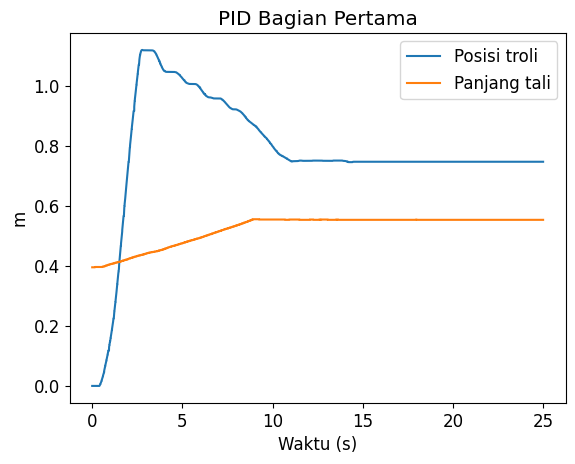

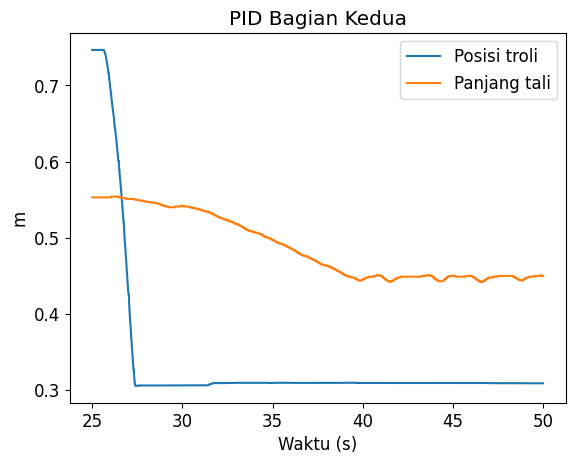

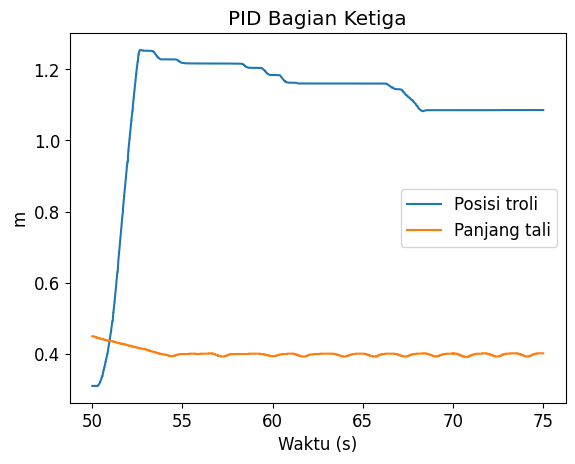

In [10]:
PID_total_time = PID_dataset["time"][-1]

PID_first_section_start_index = len(PID_dataset["time"]) - 1
for i in range(len(PID_dataset["time"])):
    if PID_dataset["pwm_trolley_motor"][i] > 0:
        PID_first_section_start_index = i
        break

PID_first_section_end_index = len(PID_dataset["time"]) - 1
PID_first_section_start_time = PID_dataset["time"][PID_first_section_start_index]
for i in range(PID_first_section_start_index, len(PID_dataset["time"])):
    if PID_dataset["time"][i] - PID_first_section_start_time > DURATION:
        PID_first_section_end_index = i
        break

PID_first_section = {
    "time": PID_dataset["time"][PID_first_section_start_index:PID_first_section_end_index],
    "trolley_position": PID_dataset["trolley_position"][PID_first_section_start_index:PID_first_section_end_index],
    "cable_length": PID_dataset["cable_length"][PID_first_section_start_index:PID_first_section_end_index],
    "sway_angle": PID_dataset["sway_angle"][PID_first_section_start_index:PID_first_section_end_index],
    "pwm_trolley_motor": PID_dataset["pwm_trolley_motor"][PID_first_section_start_index:PID_first_section_end_index],
    "pwm_hoist_motor": PID_dataset["pwm_hoist_motor"][PID_first_section_start_index:PID_first_section_end_index],
}

PID_second_section_start_index = PID_first_section_end_index
for i in range(PID_first_section_end_index, len(PID_dataset["time"])):
    if PID_dataset["time"][i] > PID_total_time / 3 and PID_dataset["pwm_trolley_motor"][i] != 0:
        PID_second_section_start_index = i
        break

PID_second_section_end_index = len(PID_dataset["time"]) - 1
PID_second_section_start_time = PID_dataset["time"][PID_second_section_start_index]
for i in range(PID_second_section_start_index, len(PID_dataset["time"])):
    if PID_dataset["time"][i] - PID_second_section_start_time > DURATION:
        PID_second_section_end_index = i
        break

PID_second_section = {
    "time": PID_dataset["time"][PID_second_section_start_index:PID_second_section_end_index],
    "trolley_position": PID_dataset["trolley_position"][PID_second_section_start_index:PID_second_section_end_index],
    "cable_length": PID_dataset["cable_length"][PID_second_section_start_index:PID_second_section_end_index],
    "sway_angle": PID_dataset["sway_angle"][PID_second_section_start_index:PID_second_section_end_index],
    "pwm_trolley_motor": PID_dataset["pwm_trolley_motor"][PID_second_section_start_index:PID_second_section_end_index],
    "pwm_hoist_motor": PID_dataset["pwm_hoist_motor"][PID_second_section_start_index:PID_second_section_end_index],
}

PID_third_section_start_index = PID_second_section_end_index
for i in range(PID_second_section_end_index, len(PID_dataset["time"])):
    if PID_dataset["time"][i] > 2 * PID_total_time / 3 and PID_dataset["pwm_trolley_motor"][i] != 0:
        PID_third_section_start_index = i
        break

PID_third_section_end_index = len(PID_dataset["time"]) - 1
PID_third_section_start_time = PID_dataset["time"][PID_third_section_start_index]
for i in range(PID_third_section_start_index, len(PID_dataset["time"])):
    if PID_dataset["time"][i] - PID_third_section_start_time > DURATION:
        PID_third_section_end_index = i
        break

PID_third_section = {
    "time": PID_dataset["time"][PID_third_section_start_index:PID_third_section_end_index],
    "trolley_position": PID_dataset["trolley_position"][PID_third_section_start_index:PID_third_section_end_index],
    "cable_length": PID_dataset["cable_length"][PID_third_section_start_index:PID_third_section_end_index],
    "sway_angle": PID_dataset["sway_angle"][PID_third_section_start_index:PID_third_section_end_index],
    "pwm_trolley_motor": PID_dataset["pwm_trolley_motor"][PID_third_section_start_index:PID_third_section_end_index],
    "pwm_hoist_motor": PID_dataset["pwm_hoist_motor"][PID_third_section_start_index:PID_third_section_end_index],
}

plt.plot(PID_first_section["time"], PID_first_section["trolley_position"], label="Posisi troli")
plt.plot(PID_first_section["time"], PID_first_section["cable_length"], label="Panjang tali")
plt.xlabel("Waktu (s)")
plt.ylabel("m")
plt.title("PID Bagian Pertama")
plt.legend()
plt.show()

plt.plot(PID_second_section["time"], PID_second_section["trolley_position"], label="Posisi troli")
plt.plot(PID_second_section["time"], PID_second_section["cable_length"], label="Panjang tali")
plt.xlabel("Waktu (s)")
plt.ylabel("m")
plt.title("PID Bagian Kedua")
plt.legend()
plt.show()

plt.plot(PID_third_section["time"], PID_third_section["trolley_position"], label="Posisi troli")
plt.plot(PID_third_section["time"], PID_third_section["cable_length"], label="Panjang tali")
plt.xlabel("Waktu (s)")
plt.ylabel("m")
plt.title("PID Bagian Ketiga")
plt.legend()
plt.show()


In [11]:
SMC_sections = [SMC_first_section, SMC_second_section, SMC_third_section]
PINN_sections = [PINN_first_section, PINN_second_section, PINN_third_section]
PID_sections = [PID_first_section, PID_second_section, PID_third_section]

setpoint = [[0.75, 0.55], [0.35, 0.45], [1.1, 0.4]]
metrics = ['rise_time_x', 'settling_time_x', 'overshoot_x', 'RMSE_x', 'rise_time_l', 'settling_time_l', 'overshoot_l', 'RMSE_l', 'settling_time_theta', 'RMSE_theta', 'max_amplitude_theta', 'cost_function']

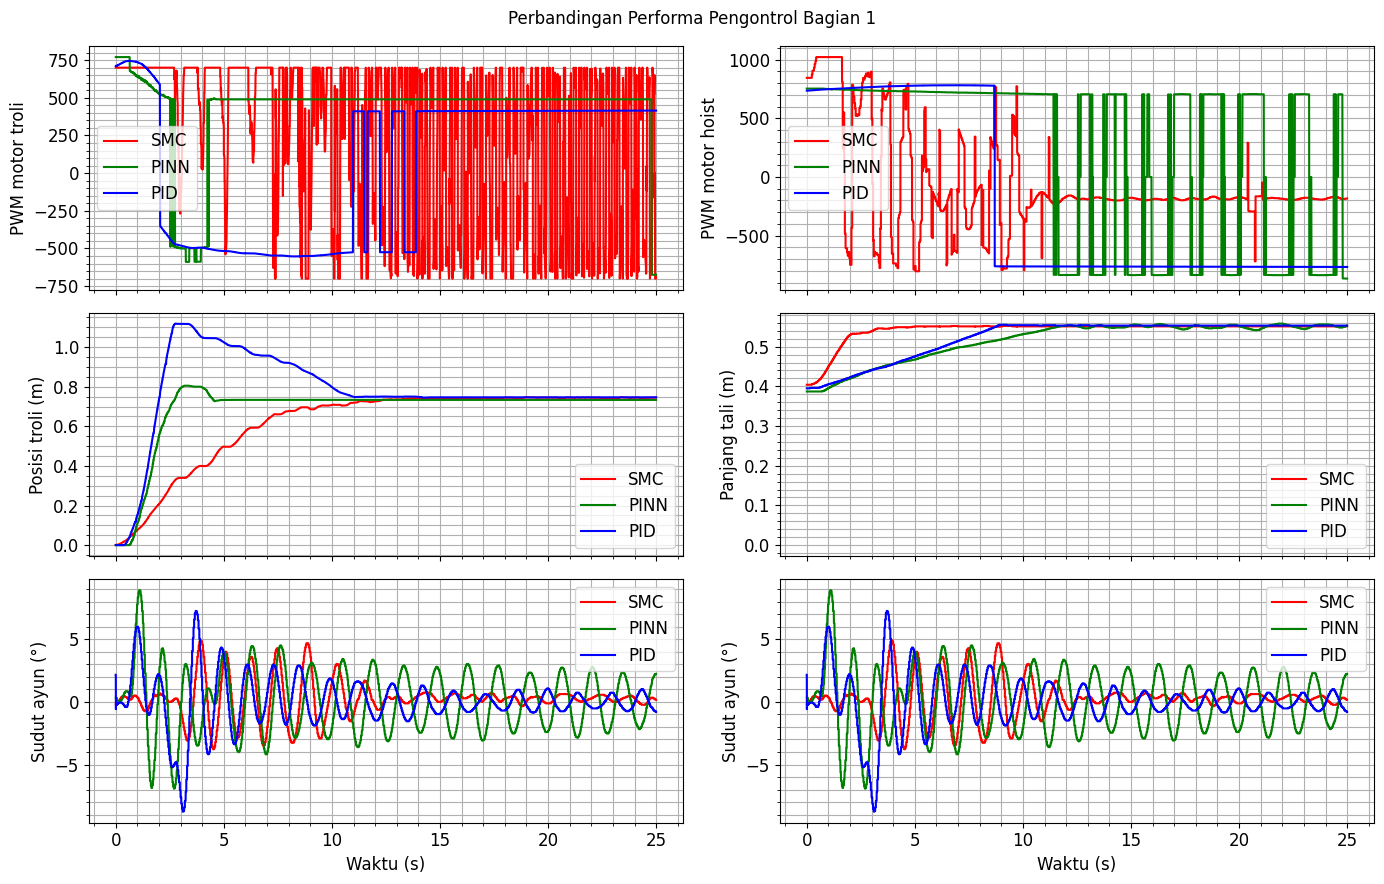

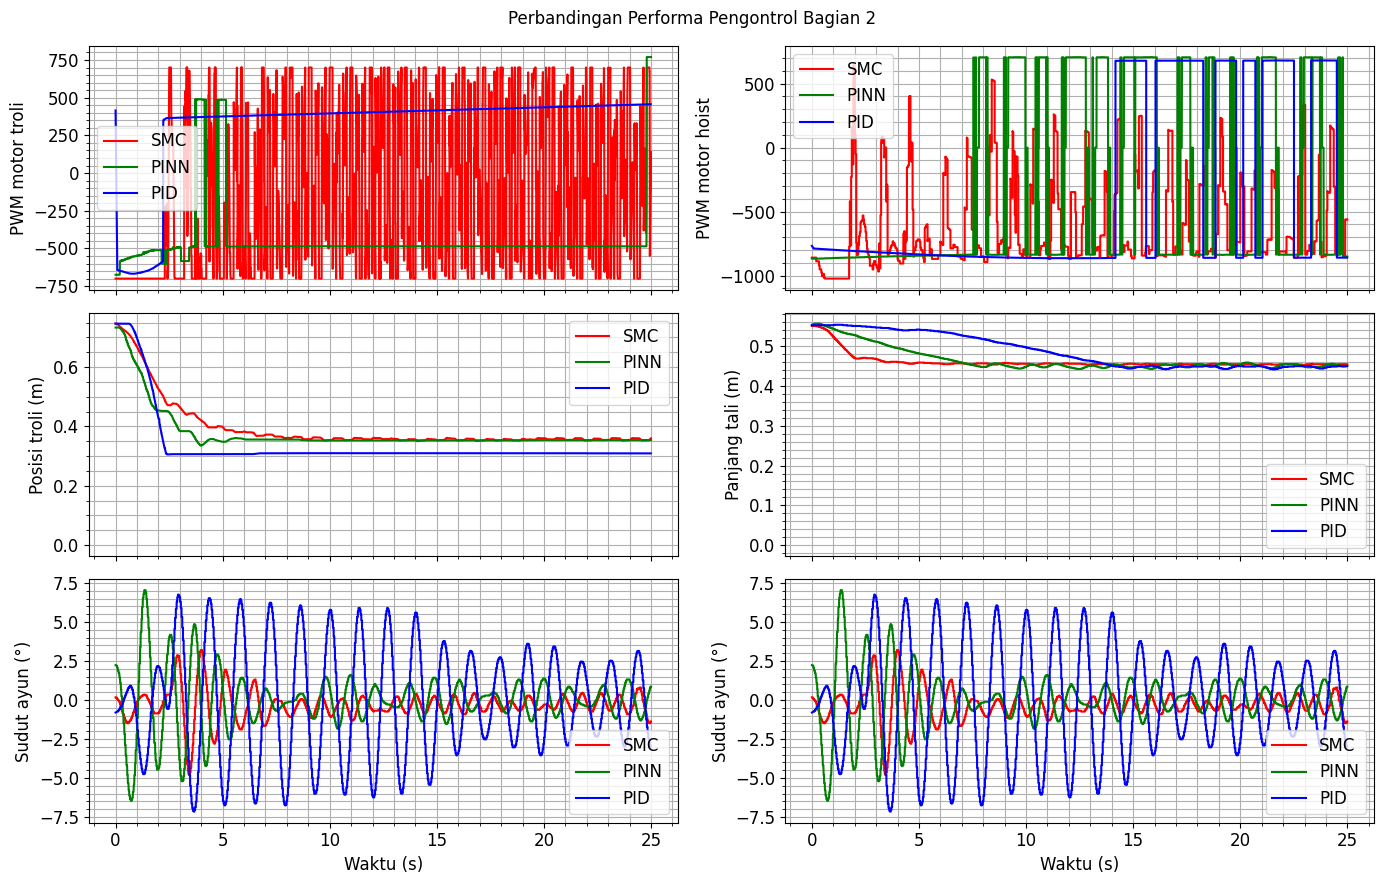

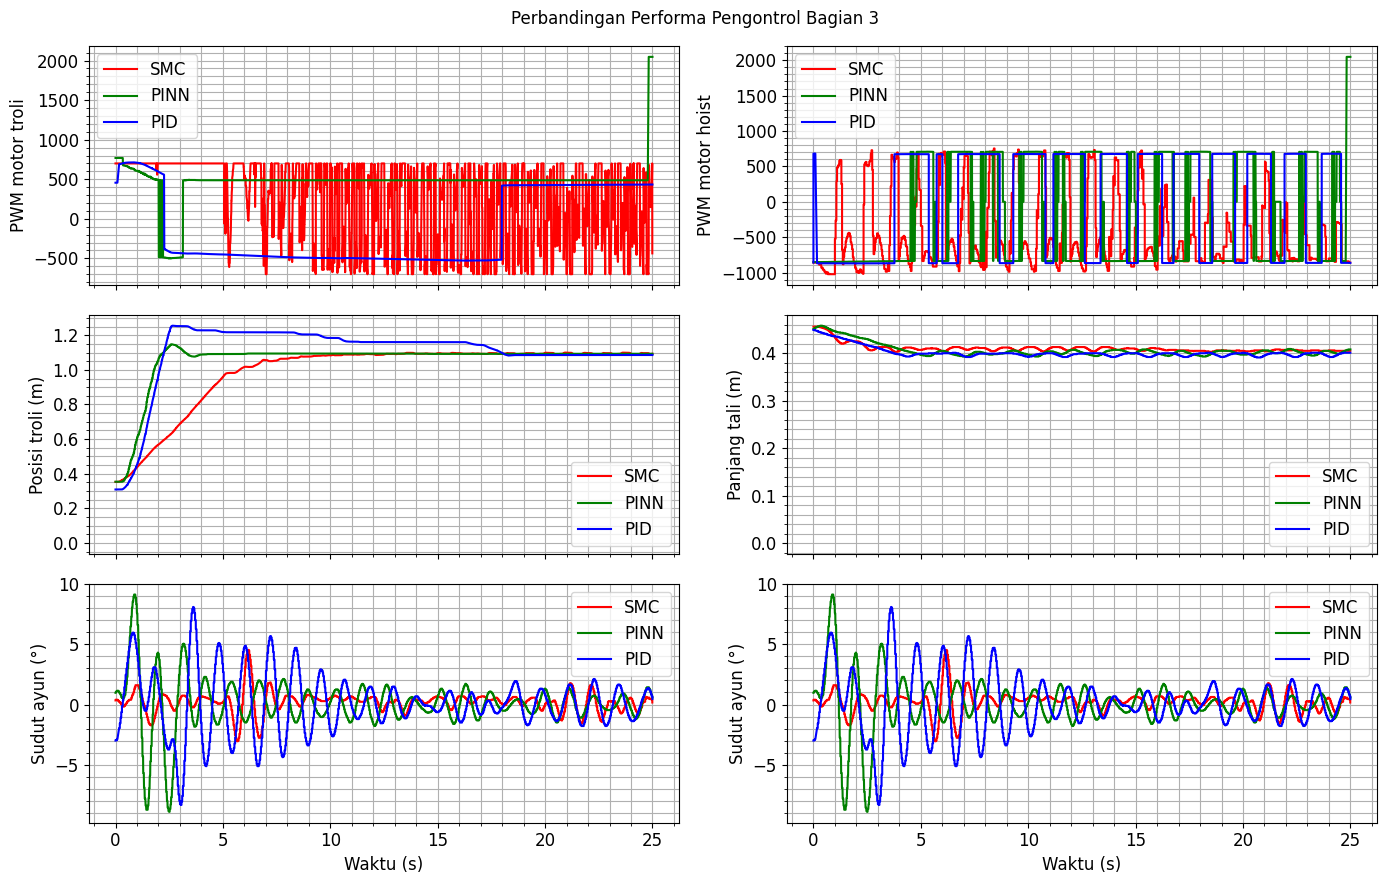

In [12]:
for index, (SMC_section, PINN_section, PID_section) in enumerate(
    zip(SMC_sections, PINN_sections, PID_sections)
):
    setpoints = {
        "x": setpoint[index][0],
        "l": setpoint[index][1],
    }

    SMC_section["time"] = SMC_section["time"] - SMC_section["time"][0]
    PINN_section["time"] = PINN_section["time"] - PINN_section["time"][0]
    PID_section["time"] = PID_section["time"] - PID_section["time"][0]

    SMC_metrics = get_quality_metrics(SMC_section, setpoints)
    PINN_metrics = get_quality_metrics(PINN_section, setpoints)
    PID_metrics = get_quality_metrics(PID_section, setpoints)

    SMC_cost = (
        SMC_metrics["rise_time_x"] ** 2
        + SMC_metrics["settling_time_x"] ** 2
        + SMC_metrics["overshoot_x"] ** 2
        + SMC_metrics["RMSE_x"] ** 2
        + SMC_metrics["rise_time_l"] ** 2
        + SMC_metrics["settling_time_l"] ** 2
        + SMC_metrics["overshoot_l"] ** 2
        + SMC_metrics["RMSE_l"] ** 2
        + SMC_metrics["settling_time_theta"] ** 2
        + SMC_metrics["RMSE_theta"] ** 2
        + SMC_metrics["max_amplitude_theta"] ** 2
    )
    SMC_cost = np.sqrt(SMC_cost / 11)
    SMC_metrics["cost_function"] = SMC_cost

    PINN_cost = (
        PINN_metrics["rise_time_x"] ** 2
        + PINN_metrics["settling_time_x"] ** 2
        + PINN_metrics["overshoot_x"] ** 2
        + PINN_metrics["RMSE_x"] ** 2
        + PINN_metrics["rise_time_l"] ** 2
        + PINN_metrics["settling_time_l"] ** 2
        + PINN_metrics["overshoot_l"] ** 2
        + PINN_metrics["RMSE_l"] ** 2
        + PINN_metrics["settling_time_theta"] ** 2
        + PINN_metrics["RMSE_theta"] ** 2
        + PINN_metrics["max_amplitude_theta"] ** 2
    )
    PINN_cost = np.sqrt(PINN_cost / 11)
    PINN_metrics["cost_function"] = PINN_cost

    PID_cost = (
        PID_metrics["rise_time_x"] ** 2
        + PID_metrics["settling_time_x"] ** 2
        + PID_metrics["overshoot_x"] ** 2
        + PID_metrics["RMSE_x"] ** 2
        + PID_metrics["rise_time_l"] ** 2
        + PID_metrics["settling_time_l"] ** 2
        + PID_metrics["overshoot_l"] ** 2
        + PID_metrics["RMSE_l"] ** 2
        + PID_metrics["settling_time_theta"] ** 2
        + PID_metrics["RMSE_theta"] ** 2
        + PID_metrics["max_amplitude_theta"] ** 2
    )
    PID_cost = np.sqrt(PID_cost / 11)
    PID_metrics["cost_function"] = PID_cost

    table_metrics = {
        "Metrik": metrics,
        "SMC": [SMC_metrics[metric] for metric in metrics],
        "PINN": [PINN_metrics[metric] for metric in metrics],
        "PID": [PID_metrics[metric] for metric in metrics],
    }

    table_metrics_df = pd.DataFrame(table_metrics)

    with pd.ExcelWriter(
        FOLDER_PATH + "controllers_comparison_metrics.xlsx",
        mode="a",
        if_sheet_exists="replace",
    ) as writer:
        table_metrics_df.to_excel(writer, sheet_name=f"Bagian {index + 1}", index=False)

    figure, axis = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
    title = f"Perbandingan Performa Pengontrol Bagian {index + 1}"
    plt.rcParams.update({"font.size": 12})
    figure.suptitle(title, fontsize=12)
    ut.add_to_subplot(
        axis[0, 0],
        SMC_section["time"],
        SMC_section["pwm_trolley_motor"],
        ylabel="SMC",
        color="red",
        linestyle="solid",
    )
    ut.add_to_subplot(
        axis[0, 1],
        SMC_section["time"],
        SMC_section["pwm_hoist_motor"],
        ylabel="SMC",
        color="red",
        linestyle="solid",
    )
    ut.add_to_subplot(
        axis[1, 0],
        SMC_section["time"],
        SMC_section["trolley_position"],
        ylabel="SMC",
        color="red",
        linestyle="solid",
    )
    ut.add_to_subplot(
        axis[1, 1],
        SMC_section["time"],
        SMC_section["cable_length"],
        ylabel="SMC",
        color="red",
        linestyle="solid",
    )
    ut.add_to_subplot(
        axis[2, 0],
        SMC_section["time"],
        np.rad2deg(SMC_section["sway_angle"]),
        ylabel="SMC",
        color="red",
        linestyle="solid",
    )
    ut.add_to_subplot(
        axis[2, 1],
        SMC_section["time"],
        np.rad2deg(SMC_section["sway_angle"]),
        ylabel="SMC",
        color="red",
        linestyle="solid",
    )

    ut.add_to_subplot(
        axis[0, 0],
        PINN_section["time"],
        PINN_section["pwm_trolley_motor"],
        ylabel="PINN",
        color="green",
        linestyle="solid",
    )
    ut.add_to_subplot(
        axis[0, 1],
        PINN_section["time"],
        PINN_section["pwm_hoist_motor"],
        ylabel="PINN",
        color="green",
        linestyle="solid",
    )
    ut.add_to_subplot(
        axis[1, 0],
        PINN_section["time"],
        PINN_section["trolley_position"],
        ylabel="PINN",
        color="green",
        linestyle="solid",
    )
    ut.add_to_subplot(
        axis[1, 1],
        PINN_section["time"],
        PINN_section["cable_length"],
        ylabel="PINN",
        color="green",
        linestyle="solid",
    )
    ut.add_to_subplot(
        axis[2, 0],
        PINN_section["time"],
        np.rad2deg(PINN_section["sway_angle"]),
        ylabel="PINN",
        color="green",
        linestyle="solid",
    )
    ut.add_to_subplot(
        axis[2, 1],
        PINN_section["time"],
        np.rad2deg(PINN_section["sway_angle"]),
        ylabel="PINN",
        color="green",
        linestyle="solid",
    )

    ut.add_to_subplot(
        axis[0, 0],
        PID_section["time"],
        PID_section["pwm_trolley_motor"],
        ylabel="PID",
        color="blue",
        linestyle="solid",
    )
    ut.add_to_subplot(
        axis[0, 1],
        PID_section["time"],
        PID_section["pwm_hoist_motor"],
        ylabel="PID",
        color="blue",
        linestyle="solid",
    )
    ut.add_to_subplot(
        axis[1, 0],
        PID_section["time"],
        PID_section["trolley_position"],
        ylabel="PID",
        color="blue",
        linestyle="solid",
    )
    ut.add_to_subplot(
        axis[1, 1],
        PID_section["time"],
        PID_section["cable_length"],
        ylabel="PID",
        color="blue",
        linestyle="solid",
    )
    ut.add_to_subplot(
        axis[2, 0],
        PID_section["time"],
        np.rad2deg(PID_section["sway_angle"]),
        ylabel="PID",
        color="blue",
        linestyle="solid",
    )
    ut.add_to_subplot(
        axis[2, 1],
        PID_section["time"],
        np.rad2deg(PID_section["sway_angle"]),
        ylabel="PID",
        color="blue",
        linestyle="solid",
    )

    axis[0, 0].legend()
    axis[0, 1].legend()
    axis[1, 0].legend()
    axis[1, 1].legend()
    axis[2, 0].legend()
    axis[2, 1].legend()

    axis[2, 0].set_xlabel("Waktu (s)", fontsize=12)
    axis[2, 1].set_xlabel("Waktu (s)", fontsize=12)

    # Set y-axis label
    axis[0, 0].set_ylabel("PWM motor troli", fontsize=12)
    axis[0, 1].set_ylabel("PWM motor hoist", fontsize=12)
    axis[1, 0].set_ylabel("Posisi troli (m)", fontsize=12)
    axis[1, 1].set_ylabel("Panjang tali (m)", fontsize=12)
    axis[2, 0].set_ylabel("Sudut ayun (°)", fontsize=12)
    axis[2, 1].set_ylabel("Sudut ayun (°)", fontsize=12)

    plt.tight_layout()
    plt.savefig(FOLDER_PATH + f"controllers_comparison_section_{index + 1}.svg")
    plt.show()

In [13]:
SMC_second_section["time"] = SMC_second_section["time"] + SMC_first_section["time"][-1]
SMC_third_section["time"] = SMC_third_section["time"] + SMC_second_section["time"][-1]
SMC_combined = {
    "time": np.concatenate((SMC_first_section["time"], SMC_second_section["time"], SMC_third_section["time"])),
    "trolley_position": np.concatenate((SMC_first_section["trolley_position"], SMC_second_section["trolley_position"], SMC_third_section["trolley_position"])),
    "cable_length": np.concatenate((SMC_first_section["cable_length"], SMC_second_section["cable_length"], SMC_third_section["cable_length"])),
    "sway_angle": np.concatenate((SMC_first_section["sway_angle"], SMC_second_section["sway_angle"], SMC_third_section["sway_angle"])),
    "pwm_trolley_motor": np.concatenate((SMC_first_section["pwm_trolley_motor"], SMC_second_section["pwm_trolley_motor"], SMC_third_section["pwm_trolley_motor"])),
    "pwm_hoist_motor": np.concatenate((SMC_first_section["pwm_hoist_motor"], SMC_second_section["pwm_hoist_motor"], SMC_third_section["pwm_hoist_motor"])),
}

PINN_second_section["time"] = PINN_second_section["time"] + PINN_first_section["time"][-1]
PINN_third_section["time"] = PINN_third_section["time"] + PINN_second_section["time"][-1]
PINN_combined = {
    "time": np.concatenate((PINN_first_section["time"], PINN_second_section["time"], PINN_third_section["time"])),
    "trolley_position": np.concatenate((PINN_first_section["trolley_position"], PINN_second_section["trolley_position"], PINN_third_section["trolley_position"])),
    "cable_length": np.concatenate((PINN_first_section["cable_length"], PINN_second_section["cable_length"], PINN_third_section["cable_length"])),
    "sway_angle": np.concatenate((PINN_first_section["sway_angle"], PINN_second_section["sway_angle"], PINN_third_section["sway_angle"])),
    "pwm_trolley_motor": np.concatenate((PINN_first_section["pwm_trolley_motor"], PINN_second_section["pwm_trolley_motor"], PINN_third_section["pwm_trolley_motor"])),
    "pwm_hoist_motor": np.concatenate((PINN_first_section["pwm_hoist_motor"], PINN_second_section["pwm_hoist_motor"], PINN_third_section["pwm_hoist_motor"])),
}

PID_second_section["time"] = PID_second_section["time"] + PID_first_section["time"][-1]
PID_third_section["time"] = PID_third_section["time"] + PID_second_section["time"][-1]
PID_combined = {
    "time": np.concatenate((PID_first_section["time"], PID_second_section["time"], PID_third_section["time"])),
    "trolley_position": np.concatenate((PID_first_section["trolley_position"], PID_second_section["trolley_position"], PID_third_section["trolley_position"])),
    "cable_length": np.concatenate((PID_first_section["cable_length"], PID_second_section["cable_length"], PID_third_section["cable_length"])),
    "sway_angle": np.concatenate((PID_first_section["sway_angle"], PID_second_section["sway_angle"], PID_third_section["sway_angle"])),
    "pwm_trolley_motor": np.concatenate((PID_first_section["pwm_trolley_motor"], PID_second_section["pwm_trolley_motor"], PID_third_section["pwm_trolley_motor"])),
    "pwm_hoist_motor": np.concatenate((PID_first_section["pwm_hoist_motor"], PID_second_section["pwm_hoist_motor"], PID_third_section["pwm_hoist_motor"])),
}


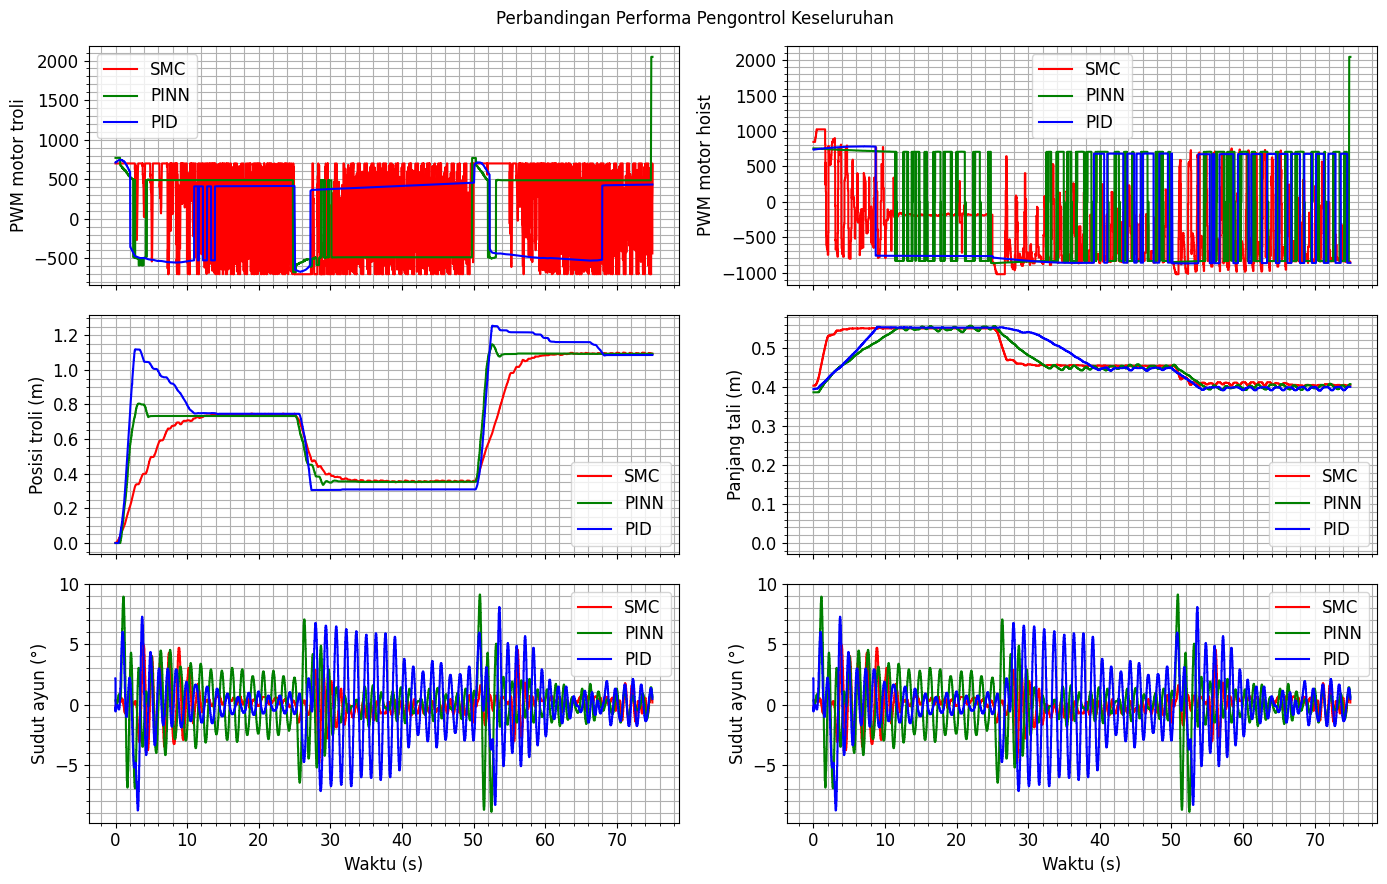

In [14]:
figure, axis = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
title = "Perbandingan Performa Pengontrol Keseluruhan"
plt.rcParams.update({"font.size": 12})
figure.suptitle(title, fontsize=12)

ut.add_to_subplot(axis[0, 0], SMC_combined["time"], SMC_combined["pwm_trolley_motor"], ylabel="SMC", color='red', linestyle="solid")
ut.add_to_subplot(axis[0, 1], SMC_combined["time"], SMC_combined["pwm_hoist_motor"], ylabel="SMC", color='red', linestyle="solid")
ut.add_to_subplot(axis[1, 0], SMC_combined["time"], SMC_combined["trolley_position"], ylabel="SMC", color='red', linestyle="solid")
ut.add_to_subplot(axis[1, 1], SMC_combined["time"], SMC_combined["cable_length"], ylabel="SMC", color='red', linestyle="solid")
ut.add_to_subplot(axis[2, 0], SMC_combined["time"], np.rad2deg(SMC_combined["sway_angle"]), ylabel="SMC", color='red', linestyle="solid")
ut.add_to_subplot(axis[2, 1], SMC_combined["time"], np.rad2deg(SMC_combined["sway_angle"]), ylabel="SMC", color='red', linestyle="solid")

ut.add_to_subplot(axis[0, 0], PINN_combined["time"], PINN_combined["pwm_trolley_motor"], ylabel="PINN", color='green', linestyle="solid")
ut.add_to_subplot(axis[0, 1], PINN_combined["time"], PINN_combined["pwm_hoist_motor"], ylabel="PINN", color='green', linestyle="solid")
ut.add_to_subplot(axis[1, 0], PINN_combined["time"], PINN_combined["trolley_position"], ylabel="PINN", color='green', linestyle="solid")
ut.add_to_subplot(axis[1, 1], PINN_combined["time"], PINN_combined["cable_length"], ylabel="PINN", color='green', linestyle="solid")
ut.add_to_subplot(axis[2, 0], PINN_combined["time"], np.rad2deg(PINN_combined["sway_angle"]), ylabel="PINN", color='green', linestyle="solid")
ut.add_to_subplot(axis[2, 1], PINN_combined["time"], np.rad2deg(PINN_combined["sway_angle"]), ylabel="PINN", color='green', linestyle="solid")

ut.add_to_subplot(axis[0, 0], PID_combined["time"], PID_combined["pwm_trolley_motor"], ylabel="PID", color='blue', linestyle="solid")
ut.add_to_subplot(axis[0, 1], PID_combined["time"], PID_combined["pwm_hoist_motor"], ylabel="PID", color='blue', linestyle="solid")
ut.add_to_subplot(axis[1, 0], PID_combined["time"], PID_combined["trolley_position"], ylabel="PID", color='blue', linestyle="solid")
ut.add_to_subplot(axis[1, 1], PID_combined["time"], PID_combined["cable_length"], ylabel="PID", color='blue', linestyle="solid")
ut.add_to_subplot(axis[2, 0], PID_combined["time"], np.rad2deg(PID_combined["sway_angle"]), ylabel="PID", color='blue', linestyle="solid")
ut.add_to_subplot(axis[2, 1], PID_combined["time"], np.rad2deg(PID_combined["sway_angle"]), ylabel="PID", color='blue', linestyle="solid")

axis[0, 0].legend()
axis[0, 1].legend()
axis[1, 0].legend()
axis[1, 1].legend()
axis[2, 0].legend()
axis[2, 1].legend()

axis[2, 0].set_xlabel("Waktu (s)", fontsize=12)
axis[2, 1].set_xlabel("Waktu (s)", fontsize=12)

# Set y-axis label
axis[0, 0].set_ylabel("PWM motor troli", fontsize=12)
axis[0, 1].set_ylabel("PWM motor hoist", fontsize=12)
axis[1, 0].set_ylabel("Posisi troli (m)", fontsize=12)
axis[1, 1].set_ylabel("Panjang tali (m)", fontsize=12)
axis[2, 0].set_ylabel("Sudut ayun (°)", fontsize=12)
axis[2, 1].set_ylabel("Sudut ayun (°)", fontsize=12)

plt.tight_layout()
plt.savefig(FOLDER_PATH + "controllers_overall_comparison.svg")
plt.show()
